In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import glob
import pandas as pd
import datetime
import numpy as np

# 파일 용량 확인
def get_csv_file_sizes(DIR):
    file_sizes = {}
    for filename in os.listdir(DIR):
        if filename.endswith('.csv'):
            file_path = os.path.join(DIR, filename)
            file_size_bytes = os.path.getsize(file_path)
            file_size_mb = file_size_bytes / (1024 * 1024)
            file_sizes[filename] = file_size_mb
    return file_sizes

# DATA2
주제 2. 구독서비스 프로덕트 데이터 분석

In [ ]:
DATA_DIR = '../topic2/'
csv_file_sizes = get_csv_file_sizes(DATA_DIR)
sorted_dict = dict(sorted(csv_file_sizes.items(), key=lambda item: item[1], reverse=True))
for filename, size in sorted_dict.items():
    print(f'{filename:<50}: {size:.2f} MB')

enter_lesson_page.csv                             : 4333.97 MB
complete_lesson.csv                               : 1066.05 MB
enter_content_page.csv                            : 311.01 MB
click_lesson_page_related_question_box.csv        : 294.39 MB
enter_main_page.csv                               : 249.65 MB
enter_signup_page.csv                             : 67.48 MB
click_content_page_start_content_button.csv       : 34.80 MB
enter_payment_page.csv                            : 23.55 MB
start_content.csv                                 : 22.78 MB
end_content.csv                                   : 19.40 MB
complete_signup.csv                               : 16.56 MB
click_content_page_more_review_button.csv         : 14.64 MB
start_free_trial.csv                              : 4.28 MB
click_cancel_plan_button.csv                      : 2.56 MB
renew_subscription.csv                            : 2.45 MB
complete_subscription.csv                         : 2.26 MB
resubscribe_subscript

| #  | 컬럼명              | 컬럼 설명                                                     | 컬럼 타입  | 비고                                                                                                                                   |
|:--:|:-------------------|:-------------------------------------------------------------|:---------|:---------------------------------------------------------------------------------------------------------------------------------------|
| 1  | **city**           | 접속 위치                                                    | Object   | 국내 기준 “시” 단위로 제공하나, 서울의 경우 “구”가 특정되는 경우는 “구” 단위로 표기                                                |
| 2  | **client_event_time** | 타임스탬프 (UTC+0 기준)                                   | Object   | -                                                                                                                                     |
| 3  | **country**        | 접속 국가                                                    | Object   | -                                                                                                                                     |
| 4  | **device_carrier** | 사용 이동통신사                                             | float64  | -                                                                                                                                     |
| 5  | **device_family**  | 사용 기기 유형                                              | Object   | -                                                                                                                                     |
| 6  | **device_type**    | 사용 기기                                                   | Object   | -                                                                                                                                     |
| 7  | **event_type**     | 이벤트 유형                                                 | Object   | 테이블명과 동일                                                                                                                       |
| 8  | **language**       | 사용자 설정 언어                                            | Object   | -                                                                                                                                     |
| 9  | **os_name**        | 사용 브라우저 이름                                          | Object   | -                                                                                                                                     |
| 10 | **os_version**     | 사용 브라우저 버전                                          | Object   | -                                                                                                                                     |
| 11 | **platform**       | 사용 플랫폼                                                | Object   | -                                                                                                                                     |
| 12 | **user_id**        | 유저 id                                                    | Object   | -                                                                                                                                     |

앰플리튜드 로그, GA로그와 유사한 형태

In [ ]:
def load_preprocessing(file_name):
    # 데이터불러오기
    df = pd.read_csv(DATA_DIR+ file_name)

    display(df.head(3))

    # 공통컬럼
    df['client_event_time'] = pd.to_datetime(df['client_event_time']) + datetime.timedelta(hours = 9) # utc 0 기준이므로 +9시간 추가해줘서 대한민국에 맞춘다.
                                                                                                      # 타 국가에 대해 살펴볼 경우에는 시간대를 해당국가에 맞게 지정해줘야한다.

    # 시간대 확인
    print(f"\n\n시간최소 : {df['client_event_time'].min()} , 시간최대 :{df['client_event_time'].max()}\n")

    # 기초 정보량 확인
    isn = df.isnull().sum()
    isn_ratio = (df.isnull().sum() / df.shape[0] * 100).round(1).astype('int').astype('str') + '%'
    unq = df.nunique()
    top_frq = df.describe(include='O').loc['top']


    pre_df = pd.concat([isn,isn_ratio,unq,top_frq],axis=1)
    pre_df.columns =['결측치','결측치(%)','유니크값','최빈값']
    pre_df.index.name = 'shape : ' + str(df.shape)
    display(pre_df)
    return df

# enter.main_page.csv
- 서비스 메인페이지 진입

In [ ]:
emp = load_preprocessing('enter_main_page.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
0,Seongnam-si,2023-04-05 21:55:06,South Korea,NaN,Samsung Phone,Samsung Galaxy S21 5G,enter.main_page,Korean,Whale,1.0.0.0,Web,NaN
1,Dongdaemun-gu,2023-04-05 21:04:29,South Korea,NaN,Mac,Mac,enter.main_page,Korean,Chrome,111.0.0.0,Web,b2b31f00b82edc6419b25324a7ae41a4
2,Hwaseong-si,2023-04-05 21:01:31,South Korea,NaN,Samsung Galaxy Note,Samsung Galaxy Note10+ 5G,enter.main_page,Korean,Chrome,111.0.0.0,Web,NaN




시간최소 : 1978-01-01 19:22:27 , 시간최대 :2023-12-15 11:46:11



,결측치,결측치(%),유니크값,최빈값
"shape : (2133548, 12)",,,,
city,56988,2%,3429,Seoul
client_event_time,0,0%,2068013,NaN
country,1869,0%,172,South Korea
device_carrier,2133548,100%,0,NaN
device_family,2813,0%,677,Windows
device_type,60050,2%,529,Windows
event_type,0,0%,1,enter.main_page
language,0,0%,62,Korean
os_name,2304,0%,41,Chrome


- 최소시간이 1978년도?
- 모두 웹 / 이벤트 타입 동일
- 이동통신사 결측치 100%
- 유저id 결측치가 75%이다. 이는 로그인 정보가 없는 상태인 유저들이라고 판단해야할 듯 / 비로그인상태
- 국적이 172개나 된다..?

In [ ]:
emp['client_event_time'].dt.year.value_counts()

client_event_time
2023    1071757
2022    1061743
2021         38
1978         10
Name: count, dtype: int64

1978년도는 데이터 이슈라고 보는게 맞을듯

# enter.signup_page.csv
- 회원가입 페이지 진입

In [ ]:
esp = load_preprocessing('enter_signup_page.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
0,Seoul,2023-04-05 21:30:43,South Korea,NaN,Samsung Phone,Samsung Galaxy A51 5G,enter.signup_page,Korean,Chrome,112.0.0.0,Web,NaN
1,Seoul,2023-04-05 21:37:41,South Korea,NaN,Samsung SM-S916N,NaN,enter.signup_page,Korean,Chrome,111.0.0.0,Web,NaN
2,Seoul,2023-04-05 21:05:53,South Korea,NaN,Apple iPhone,Apple iPhone,enter.signup_page,Korean,Mobile Safari,16.4,Web,NaN




시간최소 : 2021-11-25 09:08:18 , 시간최대 :2024-01-01 08:59:22



,결측치,결측치(%),유니크값,최빈값
"shape : (596829, 12)",,,,
city,15805,2%,2471,Seoul
client_event_time,0,0%,592091,NaN
country,514,0%,180,South Korea
device_carrier,596829,100%,0,NaN
device_family,82,0%,849,Windows
device_type,29442,4%,552,Windows
event_type,0,0%,1,enter.signup_page
language,0,0%,59,Korean
os_name,75,0%,34,Chrome


- 이동 통신사는 결측치항상 0 인듯
- user_id 모두 nan이다. 회원가입 후 user_id 부여되는 듯
- 도시와 국가 최빈값을 보니 국내 위주의 서비스로 추측
- 회원가입페이지 진입 후 회원가입 완료 유저에 대해 퍼널 연결이 가능할지? -> complete.sighup과 시간대별 비교하는 수 밖에 없다. 데이터 조인은 불가     

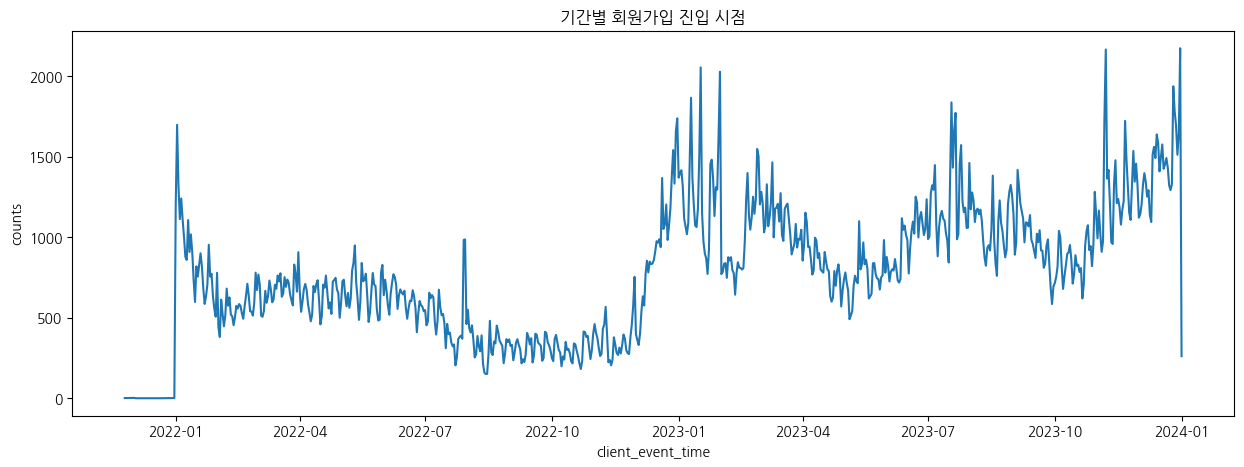

In [ ]:
esp['client_event_time'].dt.date.value_counts().sort_index().plot(figsize=(15,5))
plt.title('기간별 회원가입 진입 시점')
plt.ylabel('counts')
plt.show()

- 주말과 주중의 주기가 존재하는듯?
- 피크치는 기간에는 특정 프로모션을 했던것이 아닌가 추측 해볼 수 있음

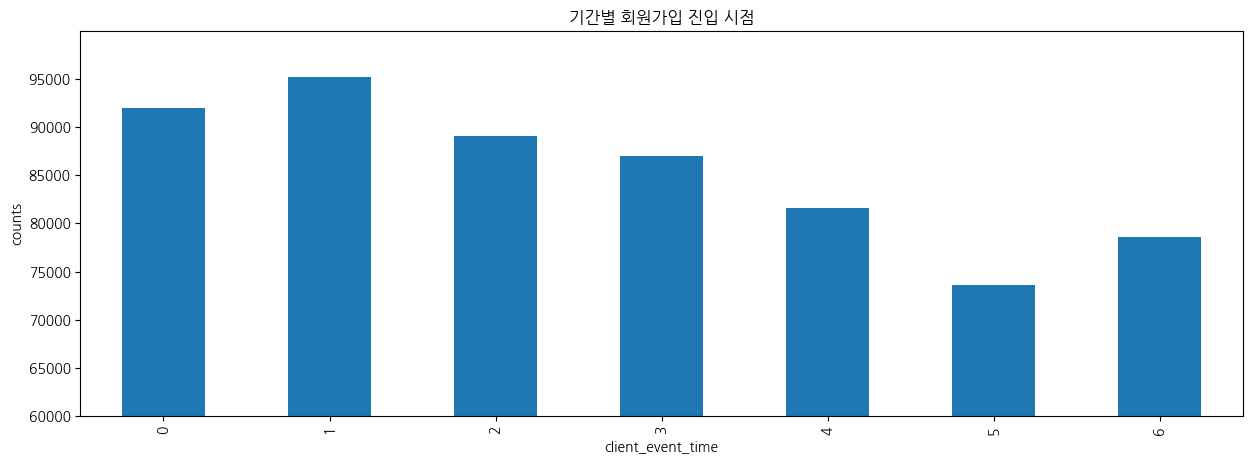

In [ ]:
esp['client_event_time'].dt.weekday.value_counts().sort_index().plot(kind='bar',figsize=(15,5)) # Monday=0, Sunday=6
plt.ylim(60000)
plt.title('기간별 회원가입 진입 시점')
plt.ylabel('counts')
plt.show()

토요일이 가장 낮은 가입진입
- 국가별로 시차 확인
- web 서비스이기 때문에 모바일 기종으로 가입하는 경우는 낮을 것이라 추측 -> 확인필요
- 데스크탑 vs 모바일의 다양한 기준으로 특성 차이 비교해보기

# complete.signup.csv
- 회원가입 완료

| 테이블명                                                | 테이블 설명                        | 컬럼명             | 타입     | 컬럼 설명                | 비고                                         |
|:--------------------------------------------------------|:-----------------------------------|:-------------------|:---------|:-------------------------|:---------------------------------------------|
|  **complete.signup**                                     | 회원가입 완료                      | type              | object   | 로그인 방식             | -                                           |

In [ ]:
csu = load_preprocessing('complete_signup.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,type
0,NaN,2023-04-05 21:33:26,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,74d17c27a41656e7788b0c81d9f76cda,kakao
1,NaN,2023-04-05 21:45:19,NaN,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,06b6868000a5d576180aca47896d6cce,kakao
2,Seo-gu,2023-04-10 14:47:56,South Korea,NaN,Windows,Windows,complete.signup,Korean,Chrome,111.0.0.0,Web,e131c319972bd580146c5a2faba26613,kakao




시간최소 : 2022-01-01 09:06:31 , 시간최대 :2024-01-01 08:51:54



,결측치,결측치(%),유니크값,최빈값
"shape : (145133, 13)",,,,
city,100359,69%,543,Seoul
client_event_time,0,0%,144861,NaN
country,99377,68%,56,South Korea
device_carrier,145133,100%,0,NaN
device_family,99366,68%,67,Windows
device_type,100474,69%,167,Windows
event_type,0,0%,1,complete.signup
language,99366,68%,16,Korean
os_name,99388,68%,19,Chrome


68%의 결측치가 일정하게 존재하는 경우들이 있다. 이는 시스템상의 업데이트로 수집 시작한 기간이 달라 발생했을 것이라 유추

In [ ]:
# %pip install missingno
import missingno

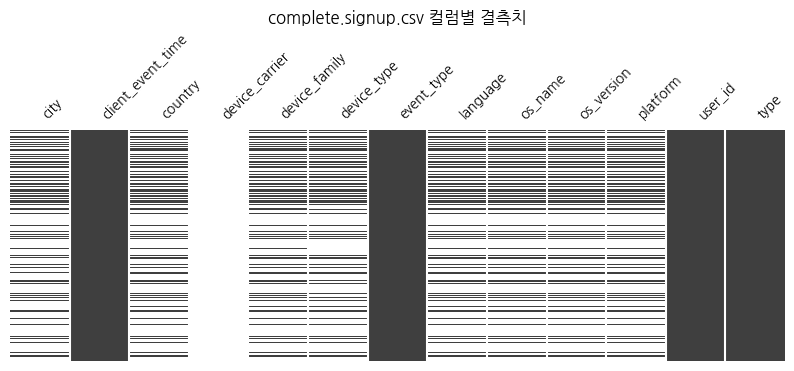

In [ ]:
missingno.matrix(csu.sort_values('client_event_time').reset_index(drop=True),figsize=(10,3),fontsize=10,sparkline=False)
plt.title('complete.signup.csv 컬럼별 결측치')
plt.yticks([])
plt.show()

- 특정기간대에 결측치가 발생하는 것은 아님
- 결측치가 있는 행은 대체로 같은 컬럼들에서 켤측치를 가진다

In [ ]:
csu['type'].value_counts()

type
kakao       89484
google      21465
naver       19440
email       14126
facebook      442
test            1
Name: count, dtype: int64

가입 경로를 확인해봤을 때, 카카오,네이버가 많다 -> 대한민국 대상 서비스
- test의 경우 개발단계의 데이터가 필터 안됐던것으로 보임 (데이터 qa팀 화이팅)
- 회원가입 시점과 비교해보기
- 국가정보도 확ㅇ니해보기~

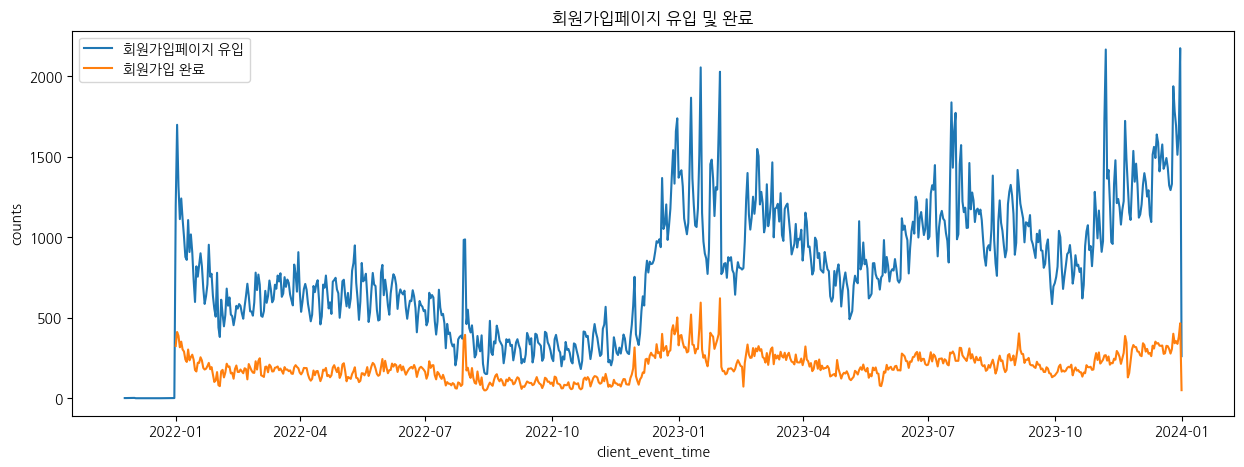

In [ ]:
esp['client_event_time'].dt.date.value_counts().sort_index().plot(figsize=(15,5),label='회원가입페이지 유입')
csu['client_event_time'].dt.date.value_counts().sort_index().plot(figsize=(15,5),label='회원가입 완료')
plt.legend()
plt.title('회원가입페이지 유입 및 완료')
plt.ylabel('counts')
plt.show()

추세는 얼추 비슷해 보인다. 실질적인 비율 상의 차이가 있는지 확인해볼 필요가 있다.
- 유입인원 대비 가입인원을 하나의 지표로 두고 기간별 차이가 있는지 확인해볼만함
- 유입인원은 튀는데 (eg. 23년 11월쯤?) 가입완료는 적은 경우

In [ ]:
csu.user_id.value_counts()

user_id
74d17c27a41656e7788b0c81d9f76cda    1
31c3a49201fa17dad325cbabf10aa71d    1
f8b8e2bfc6cf9f33d2ad7716edb02c9e    1
91e353f31d7cfc3bfb7f803fbb844730    1
57df6f623a0983e1b6ef3bda293aaaa4    1
                                   ..
7b81efed3215d9013e44409b5b0bfb31    1
de902526f47756808ee0b8609febc938    1
aa384d1fc2f3f90e77564d97a047fd05    1
742c0c521dcc0c4970f6696cd447231a    1
4252b7d6d08c1ba797ec2f5d0b244963    1
Name: count, Length: 145133, dtype: int64

모든 User_id는 고유값을 가진다 -> 하나의 id는 1개의 회원 id값을 가짐

# enter.content_page
- 콘텐츠 개별 페이지 진입

| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **enter.content_page**                              | 콘텐츠 개별 페이지 진입                 | content.id         | object | 콘텐츠 id                                       | -    |

In [ ]:
ecp = load_preprocessing('enter_content_page.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id
0,Seoul,2023-04-05 21:40:36,South Korea,NaN,Apple iPhone,Apple iPhone,enter.content_page,Korean,Chrome,108.0.5359.112,Web,d57aba7b4527e71b96135deaaec57def,220ce7873b8895d0c81c37600b5bd1e7
1,Hwaseong-si,2023-04-05 21:02:00,South Korea,NaN,Samsung Galaxy Note,Samsung Galaxy Note10+ 5G,enter.content_page,Korean,Chrome,111.0.0.0,Web,NaN,ecde9a1b01763f791c3a185d53b5f394
2,Daejeon,2023-04-05 21:13:12,South Korea,NaN,Windows,Windows,enter.content_page,Korean,Edge,111.0.1661.62,Web,41362ad5ebcade2bb1b78344a53e7ccf,b8d4ec0133e5ce485055bfd69cd28abd




시간최소 : 2021-11-04 04:15:12 , 시간최대 :2024-01-01 08:59:19



,결측치,결측치(%),유니크값,최빈값
"shape : (1914257, 13)",,,,
city,30757,1%,1866,Seoul
client_event_time,0,0%,1868099,NaN
country,7570,0%,111,South Korea
device_carrier,1914257,100%,0,NaN
device_family,639,0%,290,Windows
device_type,23651,1%,357,Windows
event_type,0,0%,1,enter.content_page
language,0,0%,35,Korean
os_name,149,0%,30,Chrome


- 유저 결측치가 25% 존재한다. 이를 어떻게 해석해야할지? 회원가입안한 유저가 컨텐츠에 속하게된건가
- 전체행은 191만행이다. 이중 유니크 유저는 7.2만으로 한 유저가 여러 컨텐츠에 포함이 되어 있을 것이다
- 전체 컨텐츠는 208개이다.
    - 컨텐츠는 처음부터 모두 존재했을지? 아니면 특정시기부터 시작되었을지 확인할 필요가 있다.
- 인기있는 컨텐츠는 무엇인지 확인해보기

In [ ]:
ecp.user_id.value_counts().head(10)

user_id
4f74b6e2f650f4c8db87579e44f5b7d6    29654
d21dc741fde11ffb6768d8bdb3547398    24270
e9261fd1140ae566bddb38c7a4c997cc     2153
2d9b821bb7ad4ae411fc3eab9c0ebfe5     1992
d3b2f51ede04364bd9861f8d261f26ec     1912
57542a51e6d83e2a11fd6f35224067d7     1874
4df798090ee2831f81ea5c60dfa15ad3     1771
681d58f5654892f6d79438751dee2b2d     1718
7d80486fc126d3d0431499fd47d1add0     1671
6b889dac8d1646374b43ccd0130182ff     1600
Name: count, dtype: int64

상위 2개 유저는 다른 유저 대비해서 상당히 많은 컨텐츠 접근이 있었다.
- 헤비유저 or 개발진 or 내부 공용아이디일 수 있다

In [ ]:
# 최고 컨텐츠 빈도 유저 데이터 확인
ecp[ecp.user_id =='4f74b6e2f650f4c8db87579e44f5b7d6'].sort_values('client_event_time').head(30)[['client_event_time','content.id','user_id']].head(20)

,client_event_time,content.id,user_id
1423058,2022-01-01 09:16:11,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6
1423059,2022-01-01 09:18:24,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6
1423060,2022-01-01 09:19:06,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6
1423061,2022-01-01 09:29:19,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6
1423062,2022-01-01 09:30:12,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6
1423063,2022-01-01 09:36:46,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6
1423064,2022-01-01 09:46:13,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6
1423065,2022-01-01 09:46:53,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6
1423066,2022-01-01 09:57:55,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6
1171991,2022-01-01 10:01:10,595cb4bbfc83e683b0314ca1312cfbde,4f74b6e2f650f4c8db87579e44f5b7d6


동일한 컨텐츠에 대해 10분간격으로 로그가 계속 남는다     
- 동일한 컨텐츠에 계속 유입되는 이유가 무엇인지 확인 불가 (아마 개발자 디버그?)
- 이상치로 봐도 될듯
- 동일한 컨텐츠에 지속적으로 로그를 남기는 시스템인지도 확인이 필요하다

In [ ]:
ecp.user_id.dropna().value_counts().describe()

count    72706.000000
mean        19.930804
std        155.091125
min          1.000000
25%          1.000000
50%          3.000000
75%         12.000000
max      29654.000000
Name: count, dtype: float64

유저별로 콘텐츠 접속에 대한 분포는 중위수가 3건, 평균 19건이다. max 2.9만건은 특이케이스 같음 자세히 볼필요있음

In [ ]:
#상위 7개의 컨텐츠가 7만명 중 1만명 이상이 시작했다.
ecp[['user_id','content.id']].dropna().drop_duplicates()['content.id'].value_counts().head(10)

content.id
f4be1a0fe0e301b03115591777fddf29    30493
61b6463287573f00de13a930805a52d6    19057
f491517f4737a60d661cd1fcacc702c0    15456
595cb4bbfc83e683b0314ca1312cfbde    12475
b314d5aba64a0aab40602cb72a4a1504    12063
c269eb6df3a374b464f7c18f12fa398f    11389
68a3658f1b936bfff3bd6960cd561b0a    11380
d6227ba76134f6cf821bb98b5f235bd0     8646
7cebec6e79cc981dbf421c5ec2aedd9d     8157
db1819d3a7a4c4d85dccb3b9e982fbcd     6678
Name: count, dtype: int64

# click.content_page_start_content_button
- 콘텐츠 시청하기 버튼 클릭

| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | content.id         | object | 콘텐츠 id                                       | -     |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button_name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 전   |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button.name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 후  |

In [ ]:
csb = load_preprocessing('click_content_page_start_content_button.csv')

/var/folders/0c/m1b4q_z52zld8x37by80fyv00000gn/T/ipykernel_22989/2317710593.py:3: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_DIR+ file_name)


,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,button.name,button_name
0,Daejeon,2023-04-05 21:14:38,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Edge,111.0.1661.62,Web,41362ad5ebcade2bb1b78344a53e7ccf,445fac33232adcb3d1cdab7d8a579430,콘텐츠 구독하기,NaN
1,Seongnam-si,2023-04-10 14:57:20,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Edge,112.0.1722.34,Web,f7155af01d277f11b1c7d05cf772c686,18992b667be06d6f29ba0008f99d9745,콘텐츠 이어보기,NaN
2,Yangp'yong,2023-04-10 14:28:30,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,111.0.0.0,Web,1b05f9fe82b80771323caa1cd5683143,dfbdae782996c25daed7517b8835f3aa,콘텐츠 이어보기,NaN




시간최소 : 2021-11-26 03:40:51 , 시간최대 :2024-01-01 08:51:15



,결측치,결측치(%),유니크값,최빈값
"shape : (172911, 15)",,,,
city,3474,2%,842,Seoul
client_event_time,0,0%,168215,NaN
country,1416,0%,58,South Korea
device_carrier,172911,100%,0,NaN
device_family,0,0%,144,Windows
device_type,1330,0%,232,Windows
event_type,0,0%,1,click.content_page_start_content_button
language,0,0%,18,Korean
os_name,0,0%,25,Chrome


- 컨텐츠 시청하기 버튼의 경우 유니크 값이 165개이다. 컨텐츠 개별페이지 진입시 유니크값은 208개였는데 일부만 버튼이 있나? 싶음
- 유저id의 결측치는 25%이다.

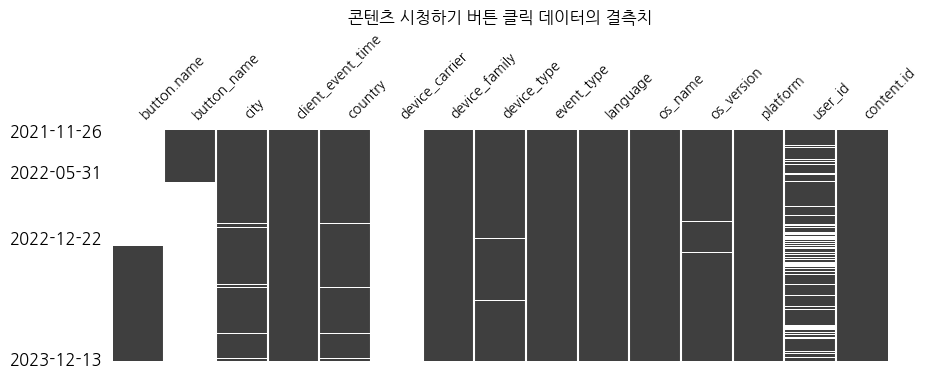

In [ ]:
sort_df = csb.sort_values('client_event_time').reset_index(drop=True)
sort_df = sort_df[list(sort_df.columns[-2:]) + list(sort_df.columns[:-2])]

missingno.matrix(sort_df,figsize=(10,3),fontsize=10,sparkline=False)
plt.yticks([0,30000,80000,170000],list(csb.sort_values('client_event_time')['client_event_time'].dt.date.iloc[[0,30000,80000,170000]].values))
plt.title('콘텐츠 시청하기 버튼 클릭 데이터의 결측치')
plt.show()

button.name의 경우 개편 후       
button_name의 경우 개편 전의 데이터를 나타낸다.    

대략 22년 5월부터 22년 12월까지는 관련 정보가 저장되어 있지 않다 -> 로그 기록이 없었던 듯

In [ ]:
csb['button.name'].unique()

array(['콘텐츠 구독하기', '콘텐츠 이어보기', '최저가 혜택 받기', '무료로 들어보기', '무료로 시작하기',
       '구독 시작하기', '최저가로 시작하기', '할인받고 구독 시작', nan], dtype=object)

In [ ]:
csb.button_name.unique()

array([nan, '이어하기', '무료로 시작하기', '수강하기', '수강시작'], dtype=object)

버튼은 각유저의 활성상태에 따른 이름 차이가 존재한다.

# click.content_page_more_review_button
- 콘텐츠 후기 더보기 버튼 클릭

| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | content.id         | object | 콘텐츠 id                                       | -     |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button_name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 전   |
| **click.content_page_start_content_button**         | 콘텐츠 시청하기 버튼 클릭               | button.name        | object | 버튼 이름                                        | 콘텐츠 페이지 개편 후  |

In [ ]:
cpmr = load_preprocessing('click_content_page_more_review_button.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id
0,Seo-gu,2023-04-10 14:10:01,South Korea,NaN,Windows,Windows,click.content_page_more_review_button,Korean,Chrome,112.0.0.0,Web,558fe7e8c06b8505f11b33d76f076e56,a1eeebeb6c307641b75b94a2a1d5b9aa
1,London,2023-01-24 21:37:43,United Kingdom,NaN,Windows,Windows,click.content_page_more_review_button,Korean,Whale,3.18.154.13,Web,e48956538e4df690a5d12adf1e6f2ee3,f491517f4737a60d661cd1fcacc702c0
2,Eunpyeong-gu,2023-01-31 14:44:17,South Korea,NaN,Windows,Windows,click.content_page_more_review_button,Korean,Chrome,109.0.0.0,Web,e745da89019e303b122bfceac0521a8f,9aa7628a347707fb155943041e2cb524




시간최소 : 2021-12-14 17:38:04 , 시간최대 :2024-01-01 03:44:14



,결측치,결측치(%),유니크값,최빈값
"shape : (93962, 13)",,,,
city,170,0%,275,Hwaseong-si
client_event_time,0,0%,24776,NaN
country,18,0%,21,South Korea
device_carrier,93962,100%,0,NaN
device_family,0,0%,20,Mac
device_type,53,0%,82,Mac
event_type,0,0%,1,click.content_page_more_review_button
language,0,0%,7,English
os_name,0,0%,18,Chrome Headless


- 유져 아이디가 88% 결측치
    - 로그인 하지 않은 상태일 때 후기를 많이 살펴본다는 의미?
    - Chrome Headless는 크롤러로 볼 수 있다.
    - 후기 수집 크롤러 ㅜㅅㅜ 나빠요

In [ ]:
cpmr[cpmr.os_name =='Chrome Headless']['client_event_time'].dt.date.value_counts().sort_index()

client_event_time
2022-01-21     8360
2022-01-23    22729
2022-01-26    18353
Name: count, dtype: int64

3일동안 크롤러의 데이터가 로그의 50%정도의 비율로 존재

# enter.payment_page

결제 페이지 진입


| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **enter.payment_page**                              | 결제 페이지 진입                        | -                  | -      | -                                                | -        |

In [ ]:
epp = load_preprocessing('enter_payment_page.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
0,Seoul,2023-04-05 21:31:28,South Korea,NaN,Samsung Phone,Samsung Galaxy A51 5G,enter.payment_page,Korean,Chrome,112.0.0.0,Web,8ee58bcaa05b234cdbf84167c0983385
1,Wonju,2023-04-05 21:33:31,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,111.0.0.0,Web,74d17c27a41656e7788b0c81d9f76cda
2,Daejeon,2023-04-05 21:05:28,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Edge,111.0.1661.62,Web,62cfa08370da60b8db4495baaff62806




시간최소 : 2022-11-03 11:39:46 , 시간최대 :2023-12-10 23:56:01



,결측치,결측치(%),유니크값,최빈값
"shape : (165061, 12)",,,,
city,2699,1%,778,Seoul
client_event_time,0,0%,144026,NaN
country,162,0%,69,South Korea
device_carrier,165061,100%,0,NaN
device_family,1,0%,131,Windows
device_type,5995,3%,229,Windows
event_type,0,0%,1,enter.payment_page
language,0,0%,18,Korean
os_name,0,0%,22,Chrome


- 관련 로그가 22년 11월 부터 수집 / 다른 대부분 데이터는 21년도부터 있어서 연결해서 살펴보기 어려운 부분이 있음, 데이터들의 공통된 시간대를 살펴보는것 필요할듯
- 결제 완료 데이터와 묶어서 결제 페이지 이탈율을 확인 해볼 수 있음
- 같은 유저가 반복적으로 결제페이지를 들어갔다면 결제 오류 or 결제 갈등(?) or 개발자..

In [ ]:
epp['user_id'].value_counts()

user_id
233094e3798cb9f681d9d1466e276ed8    101
fe3beafec5633844a56822e010bf73f9     55
d3b2f51ede04364bd9861f8d261f26ec     55
23380fbcdeecb36c1ad92a7558315b63     49
06536039eaf41ade42390ee91f5f2f5b     49
                                   ... 
711d9adb31d68e1f0eaec765f591ed97      1
fed58ff78481dc9f7a8810ebd1d25ce1      1
10e127781f9b2f6f9ffeaaea9b9362a2      1
7855e48d03e4721fd0d82fcbdafd6014      1
327605b3ab51ff70beb7b2eb60df5efd      1
Name: count, Length: 63918, dtype: int64

In [ ]:
# max 유저
# 일단위로 결제페이지를 들락날락 -> QA인듯
epp[epp.user_id =='233094e3798cb9f681d9d1466e276ed8'].sort_values('client_event_time').head(30)

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
76355,Asan,2022-12-10 02:09:04,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,108.0.0.0,Web,233094e3798cb9f681d9d1466e276ed8
74482,Asan,2022-12-10 09:48:33,South Korea,NaN,Apple iPhone,Apple iPhone XS Max,enter.payment_page,Korean,Facebook,Facebook,Web,233094e3798cb9f681d9d1466e276ed8
80183,Asan,2022-12-16 08:22:13,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,108.0.0.0,Web,233094e3798cb9f681d9d1466e276ed8
80184,Asan,2022-12-16 08:30:49,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,108.0.0.0,Web,233094e3798cb9f681d9d1466e276ed8
85614,Asan,2022-12-16 14:35:31,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,108.0.0.0,Web,233094e3798cb9f681d9d1466e276ed8
85615,Asan,2022-12-16 14:36:02,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,108.0.0.0,Web,233094e3798cb9f681d9d1466e276ed8
81670,Asan,2022-12-19 02:35:10,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,108.0.0.0,Web,233094e3798cb9f681d9d1466e276ed8
70191,Asan,2022-12-19 10:15:34,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,108.0.0.0,Web,233094e3798cb9f681d9d1466e276ed8
69114,Asan,2022-12-20 11:27:32,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,108.0.0.0,Web,233094e3798cb9f681d9d1466e276ed8
71207,Asan,2022-12-24 15:40:37,South Korea,NaN,Windows,Windows,enter.payment_page,Korean,Chrome,108.0.0.0,Web,233094e3798cb9f681d9d1466e276ed8


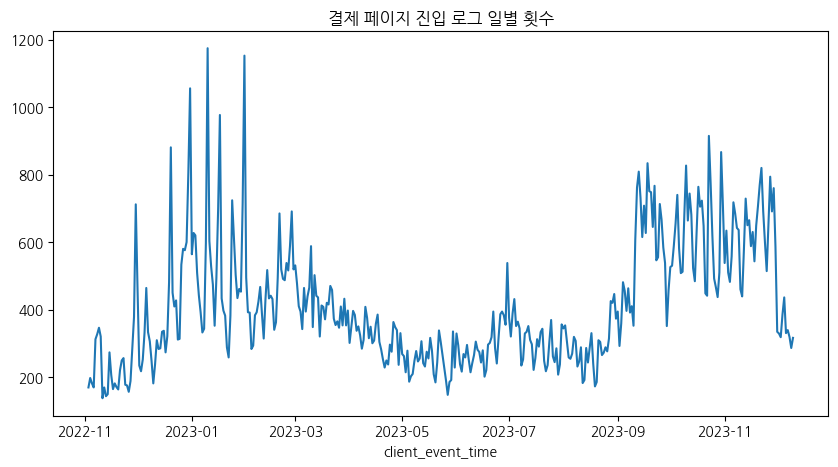

In [ ]:
epp['client_event_time'].dt.date.value_counts().sort_index().plot(figsize=(10,5))
plt.title('결제 페이지 진입 로그 일별 횟수')
plt.show()

23년 2,3분기에 상대적으로 떨어짐 / 다른기간이 프로모션등이 있었는지 확인필요

# complete.subscription
- 첫 결제 완료
- 요금제 종류, 쿠폰 종류, 쿠폰 혜택 종류, 정상가, 할인가, 할인액, 결제수단 타입
- 첫 결제가 중복인 경우는 첫 결제 환불 후 다시 결제한 케이스로 간주


| 테이블명 (이벤트명)                                | 테이블 설명                            | 컬럼명               | 타입    | 컬럼 설명                                         | 비고      |
|:----------------------------------------------------|:----------------------------------------|:--------------------|:--------|:----------------------------------|:----------|
| **complete.subscription**                         | 첫 결제 완료             | plan.price            | int64 | 정상가                                          | -|
| **complete.subscription**                         | 첫 결제 완료             | paid_amount           | int64 | 실제 결제 금액                                  | -|
| **complete.subscription**                         | 첫 결제 완료             | coupon.discount_amount | int64| 할인액                                          | 정상가 - 실제 결제 금액|
| **complete.subscription**                         | 첫 결제 완료             | pg.type               | object| 결제수단 타입                                   | A, B, C는 각기 다른 간편결제 수단|

In [ ]:
cs = load_preprocessing('complete_subscription.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,coupon.discount_amount,pg.type
0,Nowon-gu,2023-04-05 21:40:04,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Edge,111.0.1661.62,Web,1116a2ae90ca6b06f85feba27ad51ef0,15920,15920,0,NaN
1,Seoul,2023-04-10 14:20:03,South Korea,NaN,Apple iPhone,Apple iPhone,complete.subscription,Korean,Mobile Safari,16.3,Web,c0f5678df8967163e6e2c464ed006791,131600,131600,0,NaN
2,Yangsan,2023-03-12 08:46:14,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Chrome,111.0.0.0,Web,79421b5d038205ad7adbb1e2c3b89741,131600,119756,11844,NaN




시간최소 : 2022-01-01 15:17:25 , 시간최대 :2024-01-01 01:27:37



,결측치,결측치(%),유니크값,최빈값
"shape : (14289, 16)",,,,
city,532,3%,389,Seoul
client_event_time,0,0%,14196,NaN
country,383,2%,37,South Korea
device_carrier,14289,100%,0,NaN
device_family,375,2%,34,Windows
device_type,525,3%,121,Windows
event_type,0,0%,1,complete.subscription
language,375,2%,9,Korean
os_name,381,2%,18,Chrome


- 22년 1월부터 23년 12월말까지 첫결제 데이터

In [ ]:
(cs['plan.price'] - cs['paid_amount'] != cs['coupon.discount_amount']).sum()

np.int64(0)

할인금액과 실제 결제 금액간의 차이가 존재하는 행은 없다

첫 결제가 중복인 경우는 첫 결제 환불 후 다시 결제한 케이스 확인해보기

In [ ]:
multi_pay = cs.user_id.value_counts()[cs.user_id.value_counts() != 1].to_frame().rename(columns ={'count':'첫 결제 완료 횟수'})
multi_pay

,첫 결제 완료 횟수
user_id,
3767d4c7a827422fccf61d45ae889669,8
f833cca4c382ac8c502c6f99bc432725,6
ccea16701cf72a9027d7d5f2c3d3019c,5
e04c24e899b1e875ed432a7b398a4308,4
5319cec4d1e6adc224bc0c623545ac1d,3
...,...
855586c79dde036cbf240a8356f33ef1,2
9a33ed4a5be3745da60421ab3012c378,2
687b53947d8e7770779abdd9be45fc02,2


In [ ]:
print(f'첫 결제를 취소하고 여러번 한 비율은 {round(multi_pay.shape[0] / 13881,2)* 100} % 이다')

첫 결제를 취소하고 여러번 한 비율은 3.0 % 이다


In [ ]:
# ccea16701cf72a9027d7d5f2c3d3019c 유저의 첫결제 완료 시점 살펴보기
cs[cs.user_id =='ccea16701cf72a9027d7d5f2c3d3019c'][['client_event_time']].sort_values('client_event_time')

,client_event_time
13235,2023-10-20 16:01:33
11598,2023-10-23 14:26:22
13692,2023-10-26 10:12:19
11154,2023-11-13 16:44:59
11869,2023-11-23 12:04:28


첫결제를 다수 진행한 유저는 첫 결제 시점이 넓은 기간에 걸쳐 존재한다.    
이러한 경우 구매 리텐션을 확인하는데 첫 구매시점을 어떤 시점으로 봐야하는지 어려움이 있을 수 있다.     
이런 유저를 제외하고 살펴볼지 포함하고 살펴볼지는 추가적인 분석작업을 통해 진행 해보길

# renew.subscription.csv

- 정기 결제 완료

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **renew.subscription**                            | 정기 결제 완료           | plan.price            | int64 | 정상가                                          | -|
| **renew.subscription**                            | 정기 결제 완료           | paid_amount           | int64 | 실제 결제 금액                                  | -|
| **renew.subscription**                            | 정기 결제 완료           | coupon.discount_amount | int64| 할인액                                          | 정상가 - 실제 결제 금액|                              
| **renew.subscription**                            | 정기 결제 완료           | pg.type               | object| 결제수단 타입                                   | A, B, C는 각기 다른 간편결제 수단|

In [ ]:
rs = load_preprocessing('renew_subscription.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,coupon.discount_amount,pg.type
0,Nam-gu,2022-09-08 03:05:02,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Edge,104,Web,6ddea3af2eaae869861c1190dcc9d4a3,15920,15920,0,NaN
1,Nam-gu,2022-09-08 03:40:02,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,c2d47034960fdff5df495822ff66fbc1,15920,15920,0,NaN
2,Dongjak-gu,2022-09-08 03:49:01,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,de91f1226dd938990fefc79545daf468,42960,40812,2148,NaN




시간최소 : 2022-09-08 12:05:02 , 시간최대 :2024-01-01 01:10:03



,결측치,결측치(%),유니크값,최빈값
"shape : (15945, 16)",,,,
city,370,2%,421,Seoul
client_event_time,0,0%,15047,NaN
country,289,1%,39,South Korea
device_carrier,15945,100%,0,NaN
device_family,288,1%,26,Windows
device_type,461,2%,99,Windows
event_type,0,0%,1,renew.subscription
language,288,1%,9,Korean
os_name,291,1%,16,Chrome


- pg.type은 결측치가 많아서 활용에 어려움이 있어보임
- 모든 정기 결제 고객은 첫구매 데이터가 존재하는지 확인필요
- 기간은 22년 9월부터 23년 12월말까지

In [ ]:
print(f'재구매 리스트에는 있는데 첫 구매 리스트에는 없는 유저 숫자는 {len(set(rs.user_id.unique()) - set(cs.user_id.unique()))}명이다. 이는 재구매 인원의 {round(len(set(rs.user_id.unique()) - set(cs.user_id.unique())) / rs.user_id.nunique()* 100,2)} %이다.' )

재구매 리스트에는 있는데 첫 구매 리스트에는 없는 유저 숫자는 2113명이다. 이는 재구매 인원의 28.18 %이다.


첫구매가 존재하는 재구매 인원만 필터하여 재구매 하는 유저의 특성을 그렇지 않은 유저들과 비교해서 살펴보면 좋을 듯
- 어떤 유저 특성을 가지는지
- 어떤 컨텐츠를 많이 소비 했는지
- 액티브 정도는 얼마나 되는지

# resubscribe.subscription
만료 후 재구독 완료

In [ ]:
rss = load_preprocessing('resubscribe_subscription.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,coupon.discount_amount,pg.type
0,Daejeon,2023-04-05 21:11:46,South Korea,NaN,Windows,Windows,resubscribe.subscription,Korean,Edge,111.0.1661.62,Web,41362ad5ebcade2bb1b78344a53e7ccf,15920,15920,0,NaN
1,Seoul,2023-06-30 09:59:57,South Korea,NaN,Samsung Phone,Samsung Galaxy S22+,resubscribe.subscription,Korean,Chrome WebView,113.0.5672.162,Web,68831c27e47f0e8f04ba809baeec218e,15920,15920,0,NaN
2,Nowon-gu,2023-06-13 06:20:23,South Korea,NaN,Windows,Windows,resubscribe.subscription,Korean,Chrome,114.0.0.0,Web,4e7568cb7db01f8386614ec2c6c961cd,15920,15920,0,NaN




시간최소 : 2022-09-08 14:42:30 , 시간최대 :2024-01-01 02:21:27



,결측치,결측치(%),유니크값,최빈값
"shape : (791, 16)",,,,
city,16,2%,150,Seoul
client_event_time,0,0%,790,NaN
country,7,0%,12,South Korea
device_carrier,791,100%,0,NaN
device_family,7,0%,13,Windows
device_type,18,2%,33,Windows
event_type,0,0%,1,resubscribe.subscription
language,7,0%,3,Korean
os_name,7,0%,13,Chrome


- 구독 시작이 7498명인데, 재구독이 761명 뿐이다.
- 12개월 구독권도 있기에 아직 결제 시점이 도달하지 않은 유저가 존재할 수 있음

In [ ]:
print(f'재구독은 했지만 첫구독은 정보가 없는 유저는 {len(set(rss.user_id) - set(rs.user_id))}명이다.\n해당유저들이 free_trial로 시작했는지 확인 필요')

재구독은 했지만 첫구독은 정보가 없는 유저는 250명이다.
해당유저들이 free_trial로 시작했는지 확인 필요


[링크 텍스트](https://)# start.free_trial
- 서비스 무료체험 시작

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **start.free_trial**                              | 서비스 무료체험 시작      | plan.price            | int64 | 정상가                                          | -|
| **start.free_trial**                              | 서비스 무료체험 시작      | plan.type             | object| 요금제 종류                                    | -|
| **start.free_trial**                              | 서비스 무료체험 시작      | trial.type           | object| 무료체험 방식                                   | "- type A(구버전): 특정 컨텐츠 하나 영구 무료체험<br>- type B(신버전): 기간 단위로 전체 컨텐츠 경험(중복X)"|


In [ ]:
sf = load_preprocessing('start_free_trial.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,plan.type
0,Seoul,2023-04-05 21:49:36,South Korea,NaN,Mac,Mac,start.free_trial,Korean,Safari,15.6.1,Web,06b6868000a5d576180aca47896d6cce,15920.0,1개월 플랜
1,Dobong-gu,2023-03-12 08:28:29,South Korea,NaN,Windows,Windows,start.free_trial,Korean,Chrome,110.0.0.0,Web,40acc1ddfc012f3d2f58a3de95e9e748,15920.0,1개월 플랜
2,NaN,2023-03-12 08:35:00,NaN,NaN,NaN,NaN,start.free_trial,NaN,NaN,NaN,NaN,38aca03fba9753a6b2f31b829fb16a30,15920.0,1개월 플랜




시간최소 : 2021-12-04 21:46:01 , 시간최대 :2023-04-30 23:59:47



,결측치,결측치(%),유니크값,최빈값
"shape : (30621, 14)",,,,
city,488,1%,390,Seoul
client_event_time,0,0%,30402,NaN
country,130,0%,38,South Korea
device_carrier,30621,100%,0,NaN
device_family,122,0%,23,Windows
device_type,143,0%,83,Windows
event_type,0,0%,1,start.free_trial
language,122,0%,12,Korean
os_name,122,0%,16,Chrome


- 무료 체험 이후에 정기 구독을 시작하는 경우는 있는가? 있다면 그 비율은?
- 정기 구독이후에 무료체험을 하는 유저는 있는가? (데이터 오류로 보임 체크 필요)
- 무료 체험을 하는 유저는 어떤 컨텐츠를 많이 소비하는가?

In [ ]:
pd.crosstab(sf['plan.price'],sf['plan.type'])

plan.type,12개월 플랜,1개월 플랜
plan.price,,
15920.0,0,1278
131600.0,1161,0


유저의 행동별 데이터 확인 필요    
1. 무료이용 -> 첫구독 -> 재구독
2. 무료이용 -> 재구독
3. 첫구독 -> 재구독
4. 첫구독

각 항목별 예외 케이스 데이터가 분명 존재할 듯 잘 나눠서 확인 필요

# start.content
- 콘텐츠 수강 시작

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **start.content**                                 | 콘텐츠 수강 시작         | content.id            | object| 콘텐츠 id                                       | -|
| **start.content**                                 | 콘텐츠 수강 시작         | content.difficulty    | int64 | 콘텐츠 난이도                                   | -|

In [ ]:
sc = load_preprocessing('start_content.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,content.difficulty
0,Daejeon,2023-04-05 21:14:39.906000,South Korea,NaN,Windows,Windows,start.content,Korean,Edge,111.0.1661.62,Web,41362ad5ebcade2bb1b78344a53e7ccf,445fac33232adcb3d1cdab7d8a579430,beginner
1,Seoul,2023-04-05 21:50:19.674000,South Korea,NaN,Mac,Mac,start.content,Korean,Safari,15.6.1,Web,06b6868000a5d576180aca47896d6cce,f4be1a0fe0e301b03115591777fddf29,beginner
2,Seoul,2023-04-10 14:06:26.585000,South Korea,NaN,Mac,Mac,start.content,Korean,Whale,3.19.166.16,Web,7b2ff3116db46b5e4326d49c7b027631,61b6463287573f00de13a930805a52d6,beginner




시간최소 : 2022-08-17 16:11:12.230000 , 시간최대 :2024-01-01 08:43:31.046000



,결측치,결측치(%),유니크값,최빈값
"shape : (124917, 14)",,,,
city,3900,3%,723,Seoul
client_event_time,0,0%,124917,NaN
country,2885,2%,57,South Korea
device_carrier,124917,100%,0,NaN
device_family,2227,1%,91,Windows
device_type,4849,3%,199,Windows
event_type,0,0%,1,start.content
language,2225,1%,13,Korean
os_name,2246,1%,23,Chrome


- 유저 유니크 숫자는 4.2만이다
- 유저별 content.id는 시작하는 경우가 유일할 것으로 생각되는데 실제 그런지 확인 필요

In [ ]:
result = sc[['content.difficulty','user_id']].drop_duplicates()['content.difficulty'].value_counts().to_frame()
result.index.name ='난이도에 따른 시작유저 숫자'
result

,count
난이도에 따른 시작유저 숫자,
beginner,38271
intermediate,12127
advanced,9050
hard,1611


In [ ]:
sc[['user_id','content.id']].drop_duplicates()['user_id'].value_counts().head(10) # 유저의 컨텐츠 시작횟수

user_id
f59e4102149edeb73cb33ccecf95dcd9    83
28068259a009cf16d0e19ae1896b1f22    75
cc180eef3ffd3497eb8a575165bab389    74
6ffc35355c182a39e4e3739a8df0fed4    65
63518a68900f95baa9d76fb444a4e183    63
d4ab482f7d12adb21f6e9b1c68367d17    62
f70cf2877fa7fcdac2f6a42a058d231f    60
85ac0cd1c2a7fa2939df3061ec822eb1    58
5c0fe6d9885212ba763dea44677ad037    57
5b73c18042163684d08f1dc9fa82a813    56
Name: count, dtype: int64

In [ ]:
sc[['user_id','content.id']].value_counts() # 한 유저가 동일한 컨텐츠를 여러번 시청한 경우가 있다.

user_id                           content.id                      
23d69a936e8267e6f2ec7037bd3b54ca  4641438a6c81ef572d997dbdc9100f8b    8
5c2ce4062550e53fa30c3f53b8c9b181  61b6463287573f00de13a930805a52d6    7
                                  f4be1a0fe0e301b03115591777fddf29    6
40651151784699b184c58ddcd2dedf9d  c269eb6df3a374b464f7c18f12fa398f    5
a4f6eda3b4f4b0188de3b3c8ca146707  f4be1a0fe0e301b03115591777fddf29    5
                                                                     ..
550cd91e03b8e9831976d7fc2b9aadd2  18992b667be06d6f29ba0008f99d9745    1
                                  101e1d0dcc38d9c86156f008a145083e    1
550cd5457e2b55ad4b8cb6fd561d1ee1  61b6463287573f00de13a930805a52d6    1
550a71fe7cd814c818e8adf0d8305b95  f4be1a0fe0e301b03115591777fddf29    1
ffffd8d78865a66cb3706977f29d1dec  f4be1a0fe0e301b03115591777fddf29    1
Name: count, Length: 124649, dtype: int64

In [ ]:
# 위 케이스1
sc[(sc.user_id =='23d69a936e8267e6f2ec7037bd3b54ca') & (sc['content.id'] == '4641438a6c81ef572d997dbdc9100f8b')]

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,content.difficulty
50205,Siheung-si,2022-11-14 18:32:15.869,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,107,Web,23d69a936e8267e6f2ec7037bd3b54ca,4641438a6c81ef572d997dbdc9100f8b,intermediate
50206,Siheung-si,2022-11-14 18:32:15.872,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,107,Web,23d69a936e8267e6f2ec7037bd3b54ca,4641438a6c81ef572d997dbdc9100f8b,intermediate
50207,Siheung-si,2022-11-14 18:32:15.900,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,107,Web,23d69a936e8267e6f2ec7037bd3b54ca,4641438a6c81ef572d997dbdc9100f8b,intermediate
50208,Siheung-si,2022-11-14 18:32:15.904,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,107,Web,23d69a936e8267e6f2ec7037bd3b54ca,4641438a6c81ef572d997dbdc9100f8b,intermediate
50209,Siheung-si,2022-11-14 18:32:16.406,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,107,Web,23d69a936e8267e6f2ec7037bd3b54ca,4641438a6c81ef572d997dbdc9100f8b,intermediate
50210,Siheung-si,2022-11-14 18:32:16.411,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,107,Web,23d69a936e8267e6f2ec7037bd3b54ca,4641438a6c81ef572d997dbdc9100f8b,intermediate
50211,Siheung-si,2022-11-14 18:32:16.441,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,107,Web,23d69a936e8267e6f2ec7037bd3b54ca,4641438a6c81ef572d997dbdc9100f8b,intermediate
50212,Siheung-si,2022-11-14 18:32:17.309,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,107,Web,23d69a936e8267e6f2ec7037bd3b54ca,4641438a6c81ef572d997dbdc9100f8b,intermediate


1초 내에 여러번 응답이 된 것으로 보인다. 로그 이슈로 보임

In [ ]:
# 위 케이스2
# 일본..? 뭐고.. 12월 24일에 여러회차 시도했던것으로 보임
sc[(sc.user_id =='5c2ce4062550e53fa30c3f53b8c9b181') & (sc['content.id'] == '61b6463287573f00de13a930805a52d6')]

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,content.difficulty
68899,NaN,2023-10-08 19:19:19.076,Japan,NaN,Windows,Windows,start.content,Korean,Avast Secure Browser,116.0.0.0,Web,5c2ce4062550e53fa30c3f53b8c9b181,61b6463287573f00de13a930805a52d6,beginner
81347,Buk-gu,2023-12-24 16:52:11.480,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,120.0.0.0,Web,5c2ce4062550e53fa30c3f53b8c9b181,61b6463287573f00de13a930805a52d6,beginner
83677,Buk-gu,2023-12-24 19:07:00.731,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,120.0.0.0,Web,5c2ce4062550e53fa30c3f53b8c9b181,61b6463287573f00de13a930805a52d6,beginner
96856,Buk-gu,2023-12-24 22:45:48.179,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,120.0.0.0,Web,5c2ce4062550e53fa30c3f53b8c9b181,61b6463287573f00de13a930805a52d6,beginner
101490,Buk-gu,2023-12-23 10:16:44.979,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,120.0.0.0,Web,5c2ce4062550e53fa30c3f53b8c9b181,61b6463287573f00de13a930805a52d6,beginner
104507,Buk-gu,2023-12-25 05:40:41.741,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,120.0.0.0,Web,5c2ce4062550e53fa30c3f53b8c9b181,61b6463287573f00de13a930805a52d6,beginner
110833,Buk-gu,2023-12-24 21:57:33.506,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,120.0.0.0,Web,5c2ce4062550e53fa30c3f53b8c9b181,61b6463287573f00de13a930805a52d6,beginner


In [ ]:
# 위 케이스3
# 일본..? 뭐고.. 12월 24일에 여러회차 시도했던것으로 보임
sc[(sc.user_id =='40651151784699b184c58ddcd2dedf9d') & (sc['content.id'] == 'c269eb6df3a374b464f7c18f12fa398f')]

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,content.difficulty
119927,Gwangju,2023-10-09 00:40:28.619,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,117.0.0.0,Web,40651151784699b184c58ddcd2dedf9d,c269eb6df3a374b464f7c18f12fa398f,advanced
119928,Gwangju,2023-10-09 00:40:28.673,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,117.0.0.0,Web,40651151784699b184c58ddcd2dedf9d,c269eb6df3a374b464f7c18f12fa398f,advanced
119929,Gwangju,2023-10-09 00:40:28.681,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,117.0.0.0,Web,40651151784699b184c58ddcd2dedf9d,c269eb6df3a374b464f7c18f12fa398f,advanced
119930,Gwangju,2023-10-09 00:40:28.862,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,117.0.0.0,Web,40651151784699b184c58ddcd2dedf9d,c269eb6df3a374b464f7c18f12fa398f,advanced
119931,Gwangju,2023-10-09 00:40:29.188,South Korea,NaN,Windows,Windows,start.content,Korean,Chrome,117.0.0.0,Web,40651151784699b184c58ddcd2dedf9d,c269eb6df3a374b464f7c18f12fa398f,advanced


1초 내에 여러번 응답이 된 것으로 보인다. 로그 이슈로 보임
- 대체로 로그 이슈일 것이다. 중복 제거하면 유니크 케이스에 대해 확인 가능

추가질문
- 각 유저는 어떤 정기권을 통해 어떤 컨텐츠로 유입이 되었는가?
- 인기 많은 처음 시작 컨텐츠는 무엇인가
- 컨텐츠 난이도에 따른 컨텐츠 시작 양상 특징은?
- 여러 컨텐츠를 들은 유저들은 수강 패턴이 존재하는지?

# enter.lesson_page
- 콘텐츠는 여러개의 레슨로 구성되어있습니다.

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **enter.lesson_page**                             | 레슨 시작                | content.id            | object| 콘텐츠 id                                       | -|
| **enter.lesson_page**                             | 레슨 시작                | lesson.id             | object| 레슨 id                                         | -|
| **enter.lesson_page**                             | 레슨 시작                | is_free_trial         | boolean| 무료 공개 레슨 진입 여부                        | 특정 기준 시점으로 사용 안 함|
| **enter.lesson_page**                             | 레슨 시작                | is_trial              | boolean| “무료 공개 레슨 + 미구독 유저”인지 여부         | -|

In [ ]:
el = load_preprocessing('enter_lesson_page.csv')

/var/folders/0c/m1b4q_z52zld8x37by80fyv00000gn/T/ipykernel_22989/2317710593.py:3: DtypeWarning: Columns (9,13,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_DIR+ file_name)


,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,is_trial,lesson.id,is_free_trial
0,Wonju,2023-04-05 21:46:04,South Korea,NaN,Windows,Windows,enter.lesson_page,Korean,Chrome,111.0.0.0,Web,91053eda0bffb4db6c9317acf15bc44a,94bdcbd9f329aafa84ab464b6721187d,False,d360d68b65fd3e0eafb7982386d75fd9,NaN
1,Wonju,2023-04-05 21:55:51,South Korea,NaN,Windows,Windows,enter.lesson_page,Korean,Chrome,111.0.0.0,Web,91053eda0bffb4db6c9317acf15bc44a,94bdcbd9f329aafa84ab464b6721187d,False,d360d68b65fd3e0eafb7982386d75fd9,NaN
2,Wonju,2023-04-05 21:55:56,South Korea,NaN,Windows,Windows,enter.lesson_page,Korean,Chrome,111.0.0.0,Web,91053eda0bffb4db6c9317acf15bc44a,94bdcbd9f329aafa84ab464b6721187d,False,770740696ab1809d6b50d4013b64a75c,NaN




시간최소 : 2021-11-18 11:48:46 , 시간최대 :2024-01-01 08:58:48



,결측치,결측치(%),유니크값,최빈값
"shape : (21029707, 16)",,,,
city,540130,2%,1646,Seoul
client_event_time,0,0%,15292481,NaN
country,358428,1%,88,South Korea
device_carrier,21029707,100%,0,NaN
device_family,6482,0%,193,Windows
device_type,141817,0%,276,Windows
event_type,0,0%,1,enter.lesson_page
language,0,0%,25,Korean
os_name,417,0%,27,Chrome


- 행이 2천만개 있다.
- user_id가 없는 데이터가 7%... / 회원 가입을 하지 않은 유저인 것인지 로그 누락인지는 별도 확인필요
- 181개의 content와 5479개의 lesson가 존재
    - 하나의 레슨은 하나의 컨텐츠에만 종속되는지 확인 필요


In [ ]:
el[['user_id','content.id','lesson.id']].dropna().value_counts().head(20)

user_id                           content.id                        lesson.id                       
4f74b6e2f650f4c8db87579e44f5b7d6  595cb4bbfc83e683b0314ca1312cfbde  bef2ec4ced488c2bd28cbba9752f73c2    8318
                                                                    8806cdf918568960061f8de337dbbeb5    3086
                                                                    b0299c5e58b24a3a9f25004f5f057438    2101
                                                                    d5a3647122cbe5d4295753fb3debe1be    2098
                                                                    9cbb3680392236b1e16c2f2089e04519    1678
                                  f4be1a0fe0e301b03115591777fddf29  02968d35dacf2041e4067dc87d9798a2    1083
                                  595cb4bbfc83e683b0314ca1312cfbde  a5b584f8d34d88cb1e2efba8c29783b0    1021
                                  f491517f4737a60d661cd1fcacc702c0  fcb657f6e3b7e84adc5742a43e33e47d    1005
                           

하나의 유저가 한개의 컨텐츠의 하나의 레슨을 8318번 시작했다? 하루에 20번씩해도 2년이다. 뭐고 이거

In [ ]:
# 최상위 데이터의 샘플 필터
el[(el.user_id =='4f74b6e2f650f4c8db87579e44f5b7d6') & (el['content.id'] =='595cb4bbfc83e683b0314ca1312cfbde') & (el['lesson.id'] =='bef2ec4ced488c2bd28cbba9752f73c2')].sort_values('client_event_time').head(10)\
        [['city','client_event_time','user_id','lesson.id']]

,city,client_event_time,user_id,lesson.id
13933908,Yongin-si,2022-01-01 09:16:15,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2
13933910,Yongin-si,2022-01-01 09:19:12,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2
13933913,Yongin-si,2022-01-01 09:36:57,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2
13933916,Yongin-si,2022-01-01 09:57:59,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2
11972847,Yongin-si,2022-01-01 10:02:33,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2
11972848,Yongin-si,2022-01-01 10:05:27,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2
11972849,Yongin-si,2022-01-01 10:10:03,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2
11972853,Yongin-si,2022-01-01 10:15:52,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2
10456023,Yongin-si,2022-01-01 11:50:06,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2
10456028,Yongin-si,2022-01-01 11:52:56,4f74b6e2f650f4c8db87579e44f5b7d6,bef2ec4ced488c2bd28cbba9752f73c2


해당 유저는 다양한 레슨에 대해서 다양하게 시도를 했다. 용인시에 사는 서비스 개발자로 추정 (디버깅 or QA 과정의 데이터가 섞인 것으로 보임 해당 데이터들 필터 해줘야함)

In [ ]:
counts =el[el.user_id =='4f74b6e2f650f4c8db87579e44f5b7d6'].shape[0]
print(f'이상치 유저 한명이 발생시킨 시작로그 개수는 {counts}개이다. 이런 데이터는 걸러줘야한다')

이상치 유저 한명이 발생시킨 시작로그 개수는 32394개이다. 이런 데이터는 걸러줘야한다


In [ ]:
# 두번째로 로그 많은 유저
el[el.user_id =='1400ef9237d90f6e326678e7758e76ce']['lesson.id'].value_counts()

lesson.id
8ef846e922d6e7618687fda9fb5e9293    590
f8e105c3e525981bcf12bd6d6c172ad1    213
9b3c2900b1c478af4daf1c1ab4e4e93a    183
0d4be40182db15efff6f7b5f98c1706e     57
b8a5a283b9a50caf30fae81ec67baddf     46
                                   ... 
fd4f9fd9cd855c0abd59c1f3c8044412      1
92d13a9ce35f16e7335d288c8423a964      1
a6d446d134b75e2adf2c0c5c8f68cfa1      1
ac1365f5b82025beb37d5a09788cc823      1
8fdb92d40e3218f92469648fd420c031      1
Name: count, Length: 895, dtype: int64

# complete.lesson
- 레슨 완료	콘텐츠

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **complete.lesson**                               | 레슨 완료                | content.id            | object| 콘텐츠 id                                       | -|
| **complete.lesson**                               | 레슨 완료                | lesson.id             | object| 레슨 id                                         | -|

In [ ]:
cl = load_preprocessing('complete_lesson.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,lesson.id
0,Wonju,2023-04-05 21:55:52,South Korea,NaN,Windows,Windows,complete.lesson,Korean,Chrome,111.0.0.0,Web,91053eda0bffb4db6c9317acf15bc44a,94bdcbd9f329aafa84ab464b6721187d,d360d68b65fd3e0eafb7982386d75fd9
1,Daejeon,2023-04-05 21:19:01,South Korea,NaN,Windows,Windows,complete.lesson,Korean,Edge,111.0.1661.62,Web,41362ad5ebcade2bb1b78344a53e7ccf,445fac33232adcb3d1cdab7d8a579430,7e0f6aae886368ef9fa97007a8e9f7ac
2,Daejeon,2023-04-05 21:20:28,South Korea,NaN,Windows,Windows,complete.lesson,Korean,Edge,111.0.1661.62,Web,41362ad5ebcade2bb1b78344a53e7ccf,445fac33232adcb3d1cdab7d8a579430,d1e93c9dc08267efab31849bc6083854




시간최소 : 2022-01-01 09:00:01 , 시간최대 :2024-01-01 08:59:35



,결측치,결측치(%),유니크값,최빈값
"shape : (5405069, 14)",,,,
city,189679,3%,1192,Seoul
client_event_time,0,0%,5095478,NaN
country,148360,2%,67,South Korea
device_carrier,5405069,100%,0,NaN
device_family,53035,1%,111,Windows
device_type,80829,1%,204,Windows
event_type,0,0%,1,complete.lesson
language,53014,1%,16,Korean
os_name,53291,1%,23,Chrome


- 레슨 완료 데이터는 540만행
- 레슨 유니크 값은 5050개다. 레슨 시작 데이터에서 레슨 유니크 값은 5479개이다.
    - 10%정도의 데이터는 레슨 완료 케이스가 하나도 없다? -> 실제 그런것인지 확인필요
        - 레슨 완료 케이스가 없는 레슨 수강하는 동안 다른 레슨을 완료한 유저가 존재한다면 주장이 옳다고 볼 수 있다.

# click.lesson_page_related_question_box
- 레슨 페이지 내 질문 목록 클릭

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **click.lesson_page_related_question_box**        | 레슨 페이지 내 질문목록 클릭 | content.id        | object| 콘텐츠 id                                       | -|
| **click.lesson_page_related_question_box**        | 레슨 페이지 내 질문목록 클릭 | lesson.id         | object| 레슨 id                                         | -|
| **click.lesson_page_related_question_box**        | 레슨 페이지 내 질문목록 클릭 | question.id       | object| 질문 id                                         | -|

In [ ]:
clpr = load_preprocessing('click_lesson_page_related_question_box.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,question.id,content.id,lesson.id
0,Dong-gu,2023-04-05 21:51:48,South Korea,NaN,Samsung Phone,Samsung Galaxy S21 5G,click.lesson_page_related_question_box,English,Chrome,111.0.0.0,Web,117f95e12266dcf8f911ae39ff55a800,c654f9825245640595af9b8aecb150aa,c269eb6df3a374b464f7c18f12fa398f,e7dbf75457e67ef644d4ae1981b9e01b
1,Dong-gu,2023-04-05 21:52:22,South Korea,NaN,Samsung Phone,Samsung Galaxy S21 5G,click.lesson_page_related_question_box,English,Chrome,111.0.0.0,Web,117f95e12266dcf8f911ae39ff55a800,898fb79fc740dc8705b52fb32521d5d5,c269eb6df3a374b464f7c18f12fa398f,e7dbf75457e67ef644d4ae1981b9e01b
2,Dong-gu,2023-04-05 21:52:42,South Korea,NaN,Samsung Phone,Samsung Galaxy S21 5G,click.lesson_page_related_question_box,English,Chrome,111.0.0.0,Web,117f95e12266dcf8f911ae39ff55a800,9fb80c124d57fd31494738e0af5437a3,c269eb6df3a374b464f7c18f12fa398f,e7dbf75457e67ef644d4ae1981b9e01b




시간최소 : 2021-11-25 09:20:10 , 시간최대 :2024-01-01 08:51:46



,결측치,결측치(%),유니크값,최빈값
"shape : (1379136, 15)",,,,
city,23461,1%,965,Seoul
client_event_time,0,0%,1326262,NaN
country,14891,1%,54,South Korea
device_carrier,1379136,100%,0,NaN
device_family,1,0%,73,Windows
device_type,6334,0%,165,Windows
event_type,0,0%,1,click.lesson_page_related_question_box
language,0,0%,18,Korean
os_name,1,0%,22,Chrome


- 질문 목록 클릭의 활성화 정도?
- 레슨 완료율과의 연관성이 존재?

# end.content
- 콘텐츠 수강 완료
- 모든 레슨를 시청하면 해당 테이블에 로그가 쌓임

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **end.content**                                   | 수강 완료                | content.id            |       | 콘텐츠 id                                       | -|

In [ ]:
ec = load_preprocessing('end_content.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id
0,Yokohama,2023-04-10 14:02:11,Japan,NaN,Windows,Windows,end.content,Japanese,Chrome,111.0.0.0,Web,3fd801c6192296cf7b85efc01bd547b9,a914987711c7e2db9fd4bff7555ec87c
1,Seoul,2023-04-10 14:21:26,South Korea,NaN,Windows,Windows,end.content,Korean,Chrome,111.0.0.0,Web,85a332649d34bc7b5ebdec7660b1d57d,f64c475280676531a31f2f8e0648599c
2,Seongbuk-gu,2023-04-10 14:37:04,South Korea,NaN,Windows,Windows,end.content,Korean,Chrome,111.0.0.0,Web,2bf8cb1d9c5d4556f5165c2aaf804f2e,7fef928cdccef0185dfb931ef59b37d7




시간최소 : 2022-01-01 10:29:43 , 시간최대 :2024-01-01 08:23:19



,결측치,결측치(%),유니크값,최빈값
"shape : (120582, 13)",,,,
city,4302,3%,711,Seoul
client_event_time,0,0%,119997,NaN
country,3400,2%,48,South Korea
device_carrier,120582,100%,0,NaN
device_family,1191,1%,45,Windows
device_type,1716,1%,133,Windows
event_type,0,0%,1,end.content
language,1190,1%,13,Korean
os_name,1195,1%,20,Chrome


- 시작한 컨텐츠 id가 151개인데, 종료된 컨텐츠 id가 160개 이다. ㅎㅎ ;;
- 컨텐츠와 레슨의 완료의 정확한 기준(로그가 발생하는 트리거)을 알아야 추가 분석이 가능할 거 같다. 현실적으로 확인이 어렵기에 추정을 통해 진행하자
- start와 비교해서 이탈하는 유저는 어느 정도 될지?
- 중도 이탈 유저의 특징

# click.cancel_plan_button
- 구독 취소 버튼 클릭
- 구독 취소 버튼을 클릭했다면 구독 취소가 이루어진 것으로 간주

| 테이블명 (이벤트명)                               | 테이블 설명              | 컬럼명                 | 타입   | 컬럼 설명                                       | 비고 |
|:--------------------------------------------------|:------------------------|:-----------------------|:------|:------------------------------------------------|:--|
| **click.cancel_plan_button**                      | 구독 취소 버튼 클릭       | -                     | -     | -                                              | -|

In [ ]:
ccp = load_preprocessing('click_cancel_plan_button.csv')

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
0,Daegu,2023-04-10 14:57:49,South Korea,NaN,Windows,Windows,click.cancel_plan_button,Korean,Chrome,111.0.0.0,Web,9e59ecf9a8fbe9051bd0d54f4b702f30
1,Seoul,2023-03-12 08:26:16,South Korea,NaN,Apple iPad,Apple iPad,click.cancel_plan_button,English,Mobile Safari,16.3,Web,4ed4d8f12c45504a148bfff0f2e9466e
2,Uijeongbu-si,2023-03-12 08:23:05,South Korea,NaN,Windows,Windows,click.cancel_plan_button,Korean,Chrome,110.0.0.0,Web,b6a1bba3cc4139d7dc821561319221e6




시간최소 : 2021-12-04 21:53:22 , 시간최대 :2024-01-01 07:11:44



,결측치,결측치(%),유니크값,최빈값
"shape : (17895, 12)",,,,
city,153,0%,476,Seoul
client_event_time,0,0%,17884,NaN
country,2,0%,44,South Korea
device_carrier,17895,100%,0,NaN
device_family,0,0%,37,Windows
device_type,328,1%,110,Windows
event_type,0,0%,1,click.cancel_plan_button
language,0,0%,9,Korean
os_name,0,0%,19,Chrome


- 14643명이 구독을 취소했다.14643명이나 구독을 했었나..?
- 첫구독 7498 / 재구독 761 / 무료시작 16309
- 무료시작한 유저도 구독 정지를 한 케이스가 있나보다.
- 구독종료를 한 이후에 다시 구독을 시작 한 경우도 있는지 체크해보자

## DATA2 참고
- 전체 데이터에 포함된 user_id unique 파악
- 전체 데이터의 공통된 기간 영역
- 존재하는 기간이 다른 데이터 간에 해석 가능한 방법이 있을지 체크
- 개발, QA로 보이는 user_id들에 대해 판단하고 제거해주는 과정 필요
- 웹 크롤러로 보이는 (chrome headless) 로그들을 제거할 필요 있음
- 해외 이용의 비중이 적다면 확실히 제거하고 국내, 해외를 최상단에서 구분해서 분석하면 좋을듯!